<a href="https://colab.research.google.com/github/Wizako-01/neuro-mri-pipeline-python/blob/main/Neuroimaging_analysis_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install nilearn (the high-level brain tool) and nibabel (the low-level file reader)
!pip install -q nilearn nibabel matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 88.4 MB/s eta 0:00:00


[fetch_oasis_vbm] Added README.md to /root/nilearn_data

[fetch_oasis_vbm] Dataset created in /root/nilearn_data/oasis1

[fetch_oasis_vbm] Downloading data from https://www.nitrc.org/frs/download.php/6364/archive_dartel.tgz ...

[fetch_oasis_vbm] Downloaded 16039936 of 905208634 bytes (1.8%%,   55.7s remaining)

[fetch_oasis_vbm] Downloaded 35684352 of 905208634 bytes (3.9%%,   49.1s remaining)

...

[fetch_oasis_vbm] Downloaded 818470912 of 905208634 bytes (90.4%%,    2.7s remaining)

[fetch_oasis_vbm] Downloaded 863952896 of 905208634 bytes (95.4%%,    1.2s remaining)

[fetch_oasis_vbm]  ...done. (28 seconds, 0 min)

[fetch_oasis_vbm] Extracting data from 
/root/nilearn_data/oasis1/6eb7b30a1ba7e2e411dd77ca1a09e73c/archive_dartel.tgz...

[fetch_oasis_vbm] .. done.

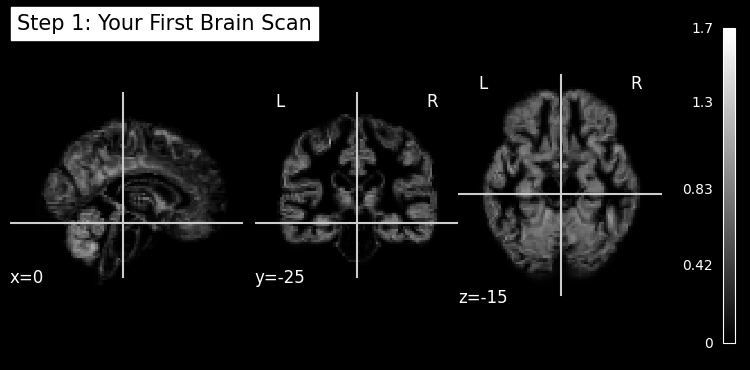

In [3]:
from nilearn import datasets, plotting

# 1. Fetch the OASIS dataset (we only need the first subject)
print("Downloading a brain scan... please wait.")
oasis_data = datasets.fetch_oasis_vbm(n_subjects=1)

# 2. Extract the file path
# This dataset gives us a "Gray Matter" map by default
t1_file = oasis_data.gray_matter_maps[0]

# 3. Plot it so we can see it
# 'ortho' shows the three planes: Axial, Coronal, and Sagittal
plotting.plot_anat(t1_file, title="Step 1: Your First Brain Scan", display_mode='ortho')

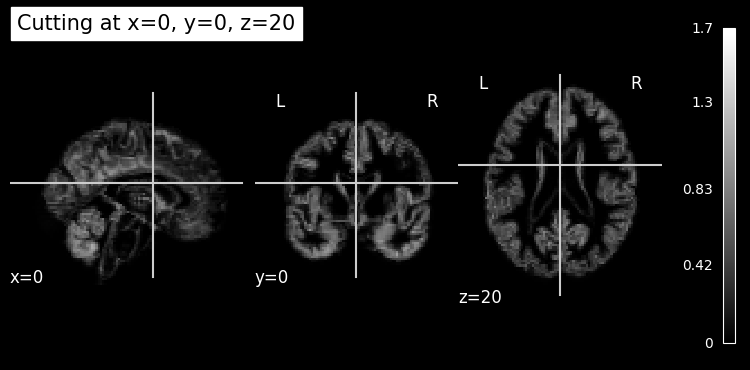

In [4]:
# We are going to pick a specific spot:
# x=0 (middle), y=0 (middle), z=20 (slightly towards the top)
coords = (0, 0, 20)

plotting.plot_anat(t1_file,
                  cut_coords=coords,
                  display_mode='ortho',
                  title="Cutting at x=0, y=0, z=20")

[fetch_atlas_harvard_oxford] Dataset created in /root/nilearn_data/fsl

[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz 
...

[fetch_atlas_harvard_oxford]  ...done. (1 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from 
/root/nilearn_data/fsl/9bcedbdf1dcbdefc71f3cd1888f3af73/HarvardOxford.tgz...

[fetch_atlas_harvard_oxford] .. done.

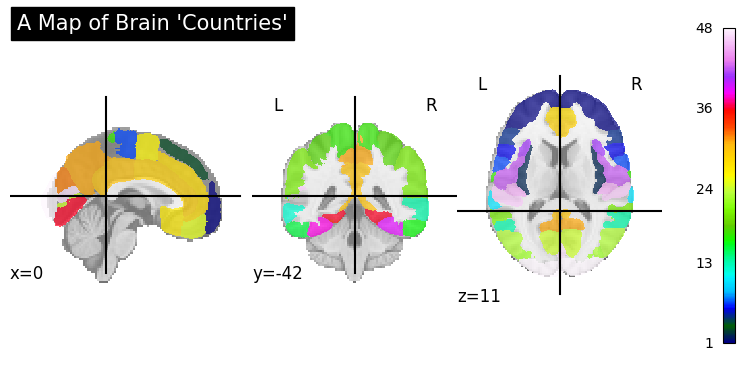

In [5]:
from nilearn import plotting, datasets

# 1. Fetch a famous Atlas (the 'Harvard-Oxford' atlas)
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-1mm')

# 2. Plot it
# Each color represents a different "country" (region) of the brain
plotting.plot_roi(atlas.maps, title="A Map of Brain 'Countries'")

plotting.show()

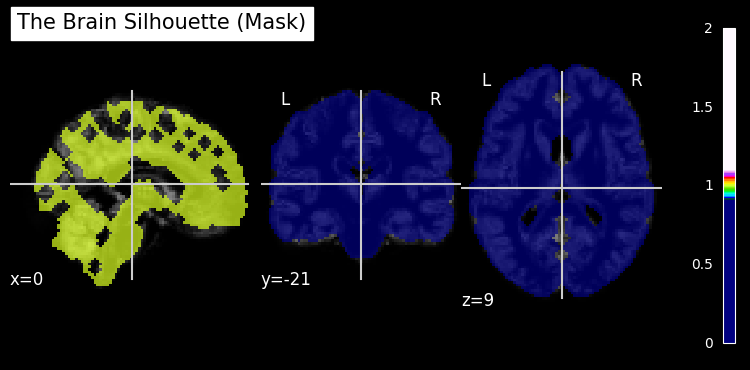

In [6]:
from nilearn import masking, plotting

# 1. Create the 'Silhouette' (The Mask)
# This looks for the darkest/lightest parts to find the brain edges
brain_mask = masking.compute_brain_mask(t1_file)

# 2. Apply the mask to the original file to "strip" the skull
# This keeps only the pixels inside the mask
brain_only = masking.apply_mask(t1_file, brain_mask)

# 3. Plot the result
# We use 'plot_roi' to show the mask we created on top of the brain
plotting.plot_roi(brain_mask, t1_file, title="The Brain Silhouette (Mask)")

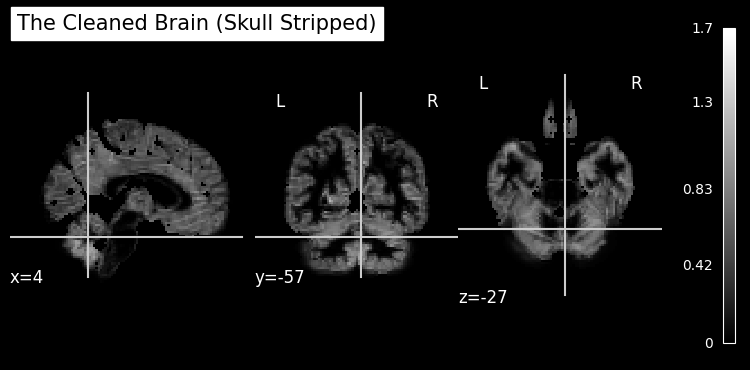

In [7]:
# 'unmask' turns the data back into a 3D brain shape after we've cleaned it
clean_brain_img = masking.unmask(brain_only, brain_mask)

plotting.plot_anat(clean_brain_img, title="The Cleaned Brain (Skull Stripped)")

# SECTION 2


In [9]:
from nilearn import datasets
import pandas as pd

# 1. Fetch 100 subjects (this includes their ages in the 'ext_vars')
data = datasets.fetch_oasis_vbm(n_subjects=100)
df = pd.DataFrame(data.ext_vars)

# 2. Find the youngest and oldest subjects
youngest_idx = df['age'].idxmin()
oldest_idx = df['age'].idxmax()

young_age = df.loc[youngest_idx, 'age']
old_age = df.loc[oldest_idx, 'age']

# 3. Get their file paths
young_brain = data.gray_matter_maps[youngest_idx]
old_brain = data.gray_matter_maps[oldest_idx]

print(f"Comparing a {young_age}-year-old vs a {old_age}-year-old.")

[fetch_oasis_vbm] Dataset found in /root/nilearn_data/oasis1

Comparing a 18-year-old vs a 90-year-old.


In [10]:
df.head(5)

,id,mf,hand,age,educ,ses,mmse,cdr,etiv,nwbv,asf,delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


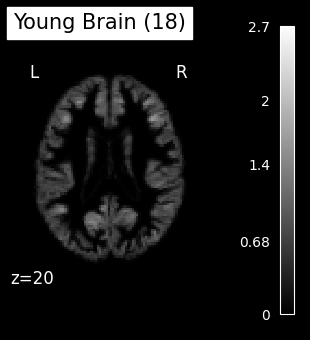

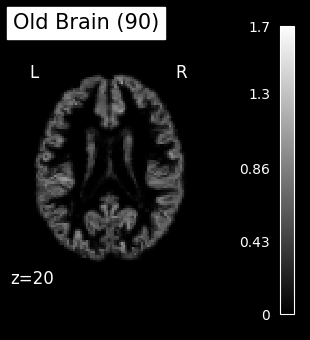

In [11]:
from nilearn import plotting

# Plot Young Brain
plotting.plot_anat(young_brain, title=f"Young Brain ({young_age})", display_mode='z', cut_coords=[20])

# Plot Old Brain
plotting.plot_anat(old_brain, title=f"Old Brain ({old_age})", display_mode='z', cut_coords=[20])

plotting.show()

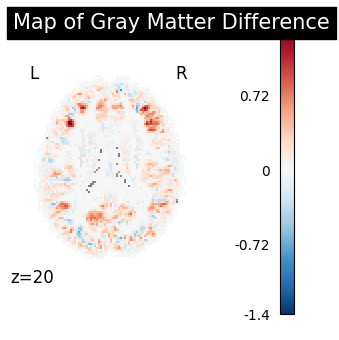

In [12]:
from nilearn import image

# Subtracting images!
# Formula: Young - Old = The difference
difference_map = image.math_img("img1 - img2", img1=young_brain, img2=old_brain)

# Plot the difference map
plotting.plot_stat_map(difference_map, title="Map of Gray Matter Difference", display_mode='z', cut_coords=[20])

## section 3


In [13]:
import numpy as np
import nibabel as nib

# 1. Load your original brain data
img = nib.load(t1_file)
data = img.get_fdata()

# 2. Flip it! axis=0 is the left-to-right axis
flipped_data = np.flip(data, axis=0)

# 3. Save it as a new "NIfTI" object so Nilearn can read it
flipped_img = nib.Nifti1Image(flipped_data, img.affine, img.header)

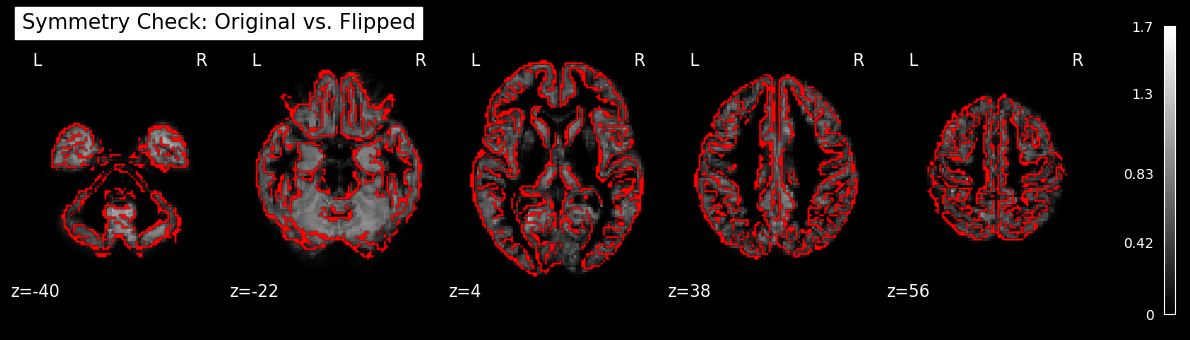

In [14]:
from nilearn import plotting

# 1. Plot the original brain first
display = plotting.plot_anat(t1_file, title="Symmetry Check: Original vs. Flipped", display_mode='z', cut_coords=5)

# 2. Add the edges of the FLIPPED brain in red
display.add_edges(flipped_img, color='r')

plotting.show()